In [3]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import cv2
import os
import tensorflow as tf
import tensorflow_hub as hub
import keras_cv
from sklearn.preprocessing import LabelEncoder
from keras import layers

In [69]:
!pip install keras_cv



  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/650.7 kB ? eta -:--:--
   ---------------------------------------- 650.7/650.7 kB 7.1 MB/s  0:00:00
   ---------------------------------------- 0.0/950.8 kB ? eta -:--:--
   ---------------------------------------- 950.8/950.8 kB 8.1 MB/s  0:00:00
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   --------------- ------------------------ 2.1/5.3 MB 10.1 MB/s eta 0:00:01
   ------------------------------- -------- 4.2/5.3 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 5.3/5.3 MB 9.0 MB/s  0:00:00
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21643 s

In [4]:
df=pd.read_csv('dataset.csv')

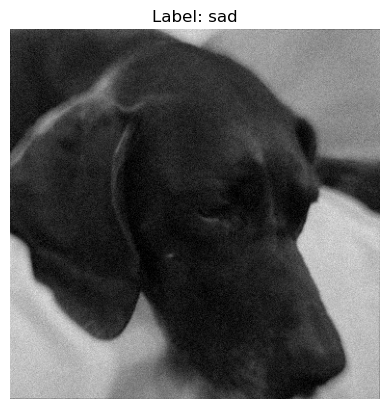

In [5]:
# Get the path and label from the first row
img_path = df.loc[0, 'image_path']
img_label = df.loc[0, 'label']

# Open and plot the image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Label: {img_label}")
plt.axis('off') # Hide graph axes
plt.show()

In [6]:
df['label'][0:3]

0        sad
1        sad
2    relaxed
Name: label, dtype: object

In [7]:
df['label'].value_counts()

label
happy      989
relaxed    979
sad        977
angry      931
Name: count, dtype: int64

#### Resizing all the images

In [8]:
# 1. Load your original CSV
# Replace with your actual CSV path and column name holding the image paths
path_column = "image_path"  # change this to match your column name

# 2. Set up the new output folder
output_folder = r"C:\Users\nihar\Documents\ML Projects\Deep Learning Projects\Dog Emotion Detection\Resized dog dataset"
os.makedirs(output_folder, exist_ok=True)

# Define target size (width, height)
TARGET_SIZE = (224, 224)

# List to store the new paths
new_paths = []

# 3. Loop through the rows, resize images, and save them
for index, row in df.iterrows():
    old_path = str(row[path_column]).strip()
    
    # Check if the original file exists before opening
    if os.path.exists(old_path):
        try:
            # Open and resize
            with Image.open(old_path) as img:
                img_resized = img.resize(TARGET_SIZE, Image.Resampling.LANCZOS)
                
                # Get the original file name (e.g., 'xwujwWRPeNhQRU8eKC81SMvBDsLquG839.jpg')
                file_name = os.path.basename(old_path)
                
                # Create the new absolute path
                new_path = os.path.join(output_folder, file_name)
                
                # Save the resized image
                img_resized.save(new_path)
                
                # Track the new path
                new_paths.append(new_path)
        except Exception as e:
            print(f"Error processing row {index}: {e}")
            new_paths.append("ERROR_PROCESSING")
    else:
        print(f"File not found at row {index}: {old_path}")
        new_paths.append("FILE_NOT_FOUND")

# 4. Update the DataFrame and save to a new CSV
df["resized_image_path"] = new_paths
df.to_csv("updated_dog_dataset.csv", index=False)

print("Done! All images resized and new CSV saved.")


Done! All images resized and new CSV saved.


In [9]:
new_df=pd.read_csv("updated_dog_dataset.csv")

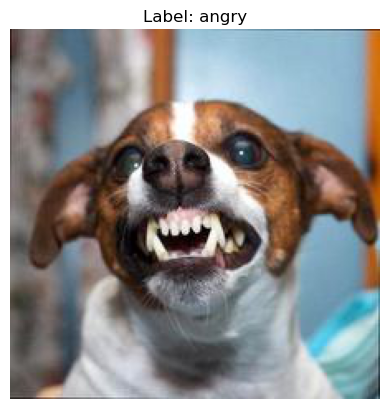

In [10]:
# Get the path and label from the first row
img_path = new_df.loc[12, 'resized_image_path']
img_label = new_df.loc[12, 'label']

# Open and plot the image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"Label: {img_label}")
plt.axis('off') # Hide graph axes
plt.show()

In [11]:
import os

# Count files in the new folder
files_in_folder = len(os.listdir(output_folder))
print(f"Total images physically in folder: {files_in_folder}")

# Count rows in your updated CSV
print(f"Total rows in your CSV: {len(df)}")


Total images physically in folder: 3876
Total rows in your CSV: 3876


#### Converting all the images into grayscale and then as single list and as numpy nd array 

In [12]:
# 1. Load all resized images into a Python list
image_list = []

print("Loading images into memory...")
for index, row in df.iterrows():
    img_path = row["resized_image_path"]
    
    # Skip rows that failed during resizing
    if img_path in ["FILE_NOT_FOUND", "ERROR_PROCESSING"]:
        continue
        
    # Read the image using OpenCV
    img = cv2.imread(img_path)
    #gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    if img is not None:
        image_list.append(img)
    else:
        print(f"Warning: Could not read image at row {index}")

# 2. Convert the list into a 4D NumPy array
dog_images = np.asarray(image_list)

# 3. Print the final shape to verify
print("Successfully loaded!")
print(f"Final array shape: {dog_images.shape}")


Loading images into memory...
Successfully loaded!
Final array shape: (3876, 224, 224, 3)


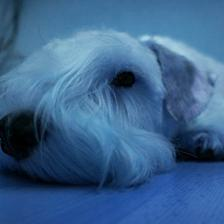

In [13]:

img = Image.fromarray(image_list[87])
img

#### Converting labels to one hot encoding

In [14]:
encoder = LabelEncoder()
Y_encoded = encoder.fit_transform(df['label'])

#### Train Test Split

In [15]:
X=dog_images
Y=Y_encoded.copy()

In [16]:
X_train_full,X_test,Y_train_full,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [17]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_full, Y_train_full, test_size=0.176, random_state=42
)

In [18]:
print(X.shape, X_train.shape, X_test.shape)


(3876, 224, 224, 3) (2554, 224, 224, 3) (776, 224, 224, 3)


In [19]:
print(Y.shape, Y_train.shape, Y_test.shape)

(3876,) (2554,) (776,)


In [20]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Now scale the data
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

#### Building the Neural Network

In [99]:
mobilenet_model= 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

In [22]:
num_of_classes=4

In [101]:
pretrained_model=keras_cv.models.ImageClassifier.from_preset(
    "mobilenet_v3_large_imagenet", 
    load_weights=True,
    num_classes=num_of_classes
)

In [102]:
model=tf.keras.Sequential([
    pretrained_model,
    tf.keras.layers.Dense(num_of_classes)
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_classifier_2              │ (None, 4)              │     3,000,196 │
│ (ImageClassifier)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,216 (11.44 MB)

 Trainable params: 2,975,816 (11.35 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [103]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [104]:
model.fit(X_train_scaled,Y_train,epochs=5) 

Epoch 1/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 429s 4s/step - acc: 0.4171 - loss: 1.3045
Epoch 2/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - acc: 0.4661 - loss: 1.2475
Epoch 3/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 308s 3s/step - acc: 0.4952 - loss: 1.2151
Epoch 4/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - acc: 0.5100 - loss: 1.1849
Epoch 5/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - acc: 0.5310 - loss: 1.1501


In [23]:
model=tf.keras.Sequential([
    layers.InputLayer(input_shape=(224,224,3)),

    layers.Conv2D(filters=10,kernel_size=(3,3),activation="relu"),
    layers.Conv2D(filters=10,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=20,kernel_size=(3,3),activation="relu"),
    layers.Conv2D(filters=20,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(100, activation="relu"), 
    
    # FIX 2: Add your true output layer matching your number of classes
    layers.Dense(num_of_classes, activation="softmax")
])

C:\Users\nihar\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [24]:
model.compile(optimizer="adam",
             loss="SparseCategoricalCrossentropy",
             metrics=["accuracy"])

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    X_train, 
    Y_train,                        # <-- Fixed: Added your training labels
    epochs=100, 
    validation_data=(X_val, Y_val), # <-- Fixed: Grouped validation images and labels together
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 321ms/step - accuracy: 0.2827 - loss: 30.5215 - val_accuracy: 0.3040 - val_loss: 1.3156
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 305ms/step - accuracy: 0.5008 - loss: 1.1394 - val_accuracy: 0.3663 - val_loss: 1.3727
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 319ms/step - accuracy: 0.7737 - loss: 0.6216 - val_accuracy: 0.3956 - val_loss: 1.5115
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 329ms/step - accuracy: 0.9421 - loss: 0.2209 - val_accuracy: 0.3645 - val_loss: 2.3737
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 323ms/step - accuracy: 0.9836 - loss: 0.0921 - val_accuracy: 0.4158 - val_loss: 2.4997
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 322ms/step - accuracy: 0.9941 - loss: 0.0419 - val_accuracy: 0.3974 - val_loss: 2.4443


In [29]:
validation_loss, validation_accuracy = model.evaluate(X_val, Y_val)

# Validation loss and accuracy
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.3040 - loss: 1.3156
Validation Loss: 1.3156386613845825
Validation Accuracy: 0.30402931571006775


In [30]:
loss,accuracy = model.evaluate(X_train,Y_train)

# Training loss and accuracy
print("Training Loss:", loss)
print("Training Accuracy:", accuracy)

80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.4640 - loss: 1.2280
Training Loss: 1.2279783487319946
Training Accuracy: 0.4639780819416046
